In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis,skew
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score, roc_curve, roc_auc_score, accuracy_score, precision_score

In [12]:
np.random.seed(0)

DESCRIPTIVE ANALYSIS

In [13]:
df = pd.read_csv('data.txt')

In [14]:
df.shape

(195, 24)

In [15]:
df.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [17]:
print(f'Dataset shape before removing duplicates is: {df.shape}')
df = df.drop_duplicates()
print(f'Dataset shape after removing duplicates is: {df.shape}')

Dataset shape before removing duplicates is: (195, 24)
Dataset shape after removing duplicates is: (195, 24)


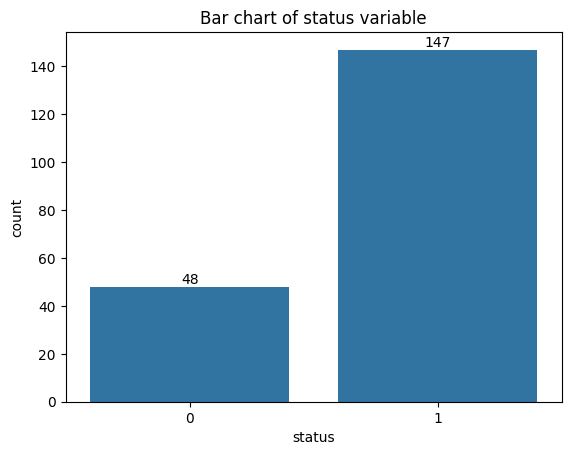

In [18]:
ax = sns.countplot(x = 'status', data = df)
ax.bar_label(ax.containers[0])
plt.title('Bar chart of status variable')
plt.show()

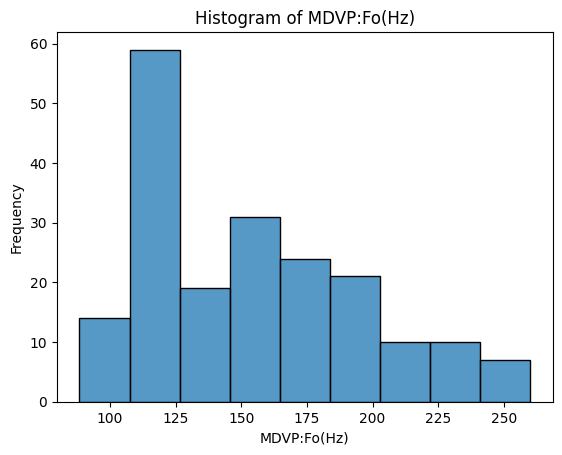

In [19]:
column = df.columns[1]
sns.histplot(data = df, x = column)
plt.title(f'Histogram of {column}')
plt.ylabel('Frequency')
plt.show()

In [20]:
description = df[column].describe()
description = description.drop('count')
description.loc['kurtosis'] = kurtosis(df[column])
description.loc['skewness'] = skew(df[column])
iqr = df[column].quantile(0.75)-df[column].quantile(0.25)
description.loc['upper bound outliers'] = len(df[df[column] > df[column].quantile(0.75) + 1.5 * iqr])
description.loc['lower bound outliers'] = len(df[df[column] < df[column].quantile(0.25) - 1.5 * iqr])
description

mean                    154.228641
std                      41.390065
min                      88.333000
25%                     117.572000
50%                     148.790000
75%                     182.769000
max                     260.105000
kurtosis                 -0.642526
skewness                  0.587176
upper bound outliers      0.000000
lower bound outliers      0.000000
Name: MDVP:Fo(Hz), dtype: float64

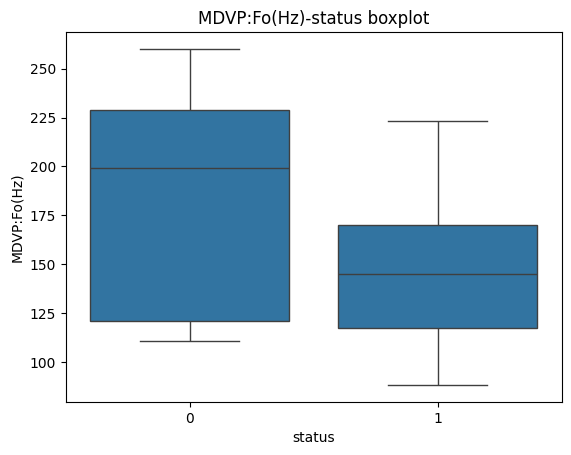

In [21]:
sns.boxplot(data = df, x = 'status', y = column)
plt.title(f'{column}-status boxplot')
plt.show()

In [22]:
description = df.groupby('status')[column].describe()
desc = description.T.drop('count')
desc

status,0,1
mean,181.937771,145.180762
std,52.731067,32.348050
min,110.739000,88.333000
25%,120.947500,117.572000
50%,198.996000,145.174000
75%,229.077000,170.071000
max,260.105000,223.361000


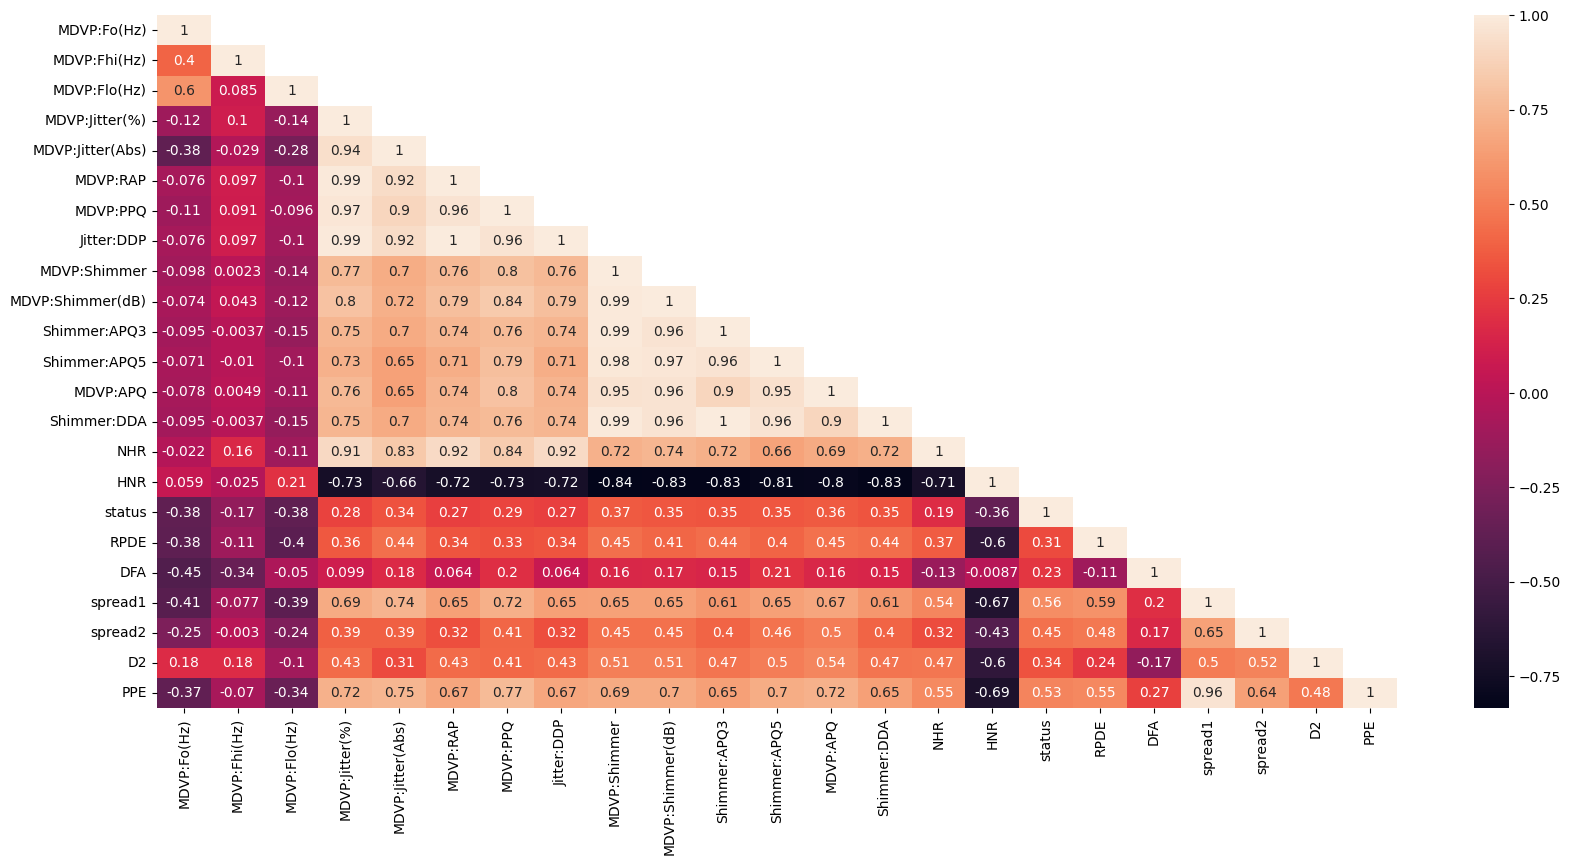

In [23]:
df_corr = df[df.columns[1:]].corr(method = 'pearson')
plt.figure(figsize = (20, 9))
mask = np.triu(np.ones_like(df_corr, dtype = bool), k = 1)
sns.heatmap(df_corr, annot = True, mask = mask)
plt.show()

IMPLEMENTATION OF METHODOLOGY

In [24]:
X = df.drop(columns = ['name', 'status'])
y = df['status']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 0)

In [26]:
print('Train set distribution')
print(y_train.value_counts())
print('Test set distribution')
print(y_test.value_counts())

Train set distribution
status
1    103
0     33
Name: count, dtype: int64
Test set distribution
status
1    44
0    15
Name: count, dtype: int64


In [27]:
dt_param_grid = {
    'max_depth' : list(range(3 , 11))
}
dt_grid_search = GridSearchCV(estimator = DecisionTreeClassifier(random_state = 0), 
                              param_grid = dt_param_grid, 
                              cv = KFold(n_splits = 10, shuffle = True, random_state = 0), 
                              scoring = 'recall', 
                              n_jobs = -1)
dt_grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='recall')

In [28]:
dt_grid_search.best_params_

{'max_depth': 4}

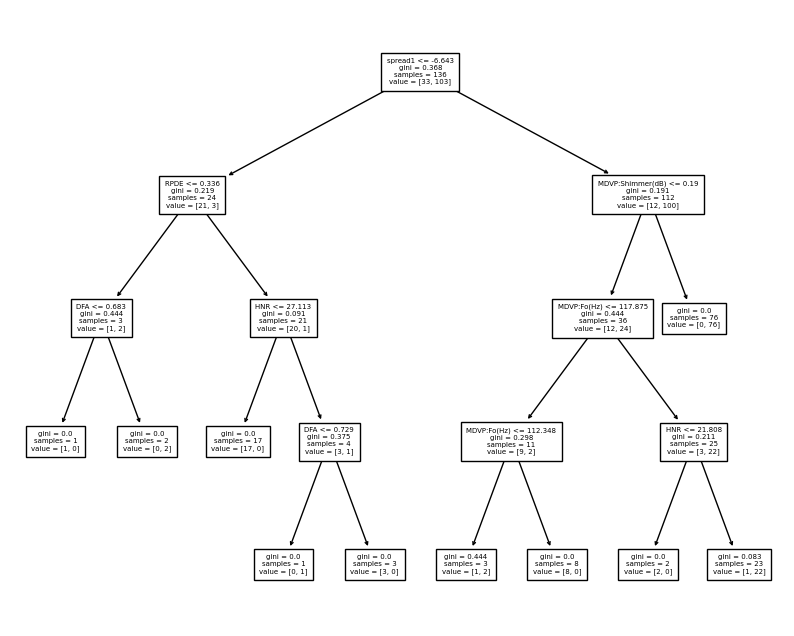

In [29]:
plt.figure(figsize = (10, 8))
plot_tree(dt_grid_search.best_estimator_, feature_names=X.columns,
          fontsize=5)
plt.show()

In [30]:
tree_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': dt_grid_search.best_estimator_.feature_importances_})
tree_df = tree_df[tree_df['Importance'] > 0].sort_values(by = 'Importance', ascending = False)
tree_df

,Feature,Importance
18,spread1,0.498658
0,MDVP:Fo(Hz),0.200832
9,MDVP:Shimmer(dB),0.116147
15,HNR,0.080698
17,DFA,0.060620
16,RPDE,0.043046


In [31]:
selected_variables = tree_df[tree_df['Importance'] > 0.1]['Feature'].tolist()
X_train = X_train[selected_variables]
X_test = X_test[selected_variables]

In [32]:
scaler = RobustScaler()
scaler.fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)
sm = SMOTE(k_neighbors = 3)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [33]:
print('Train set distribution after SMOTE process')
y_train.value_counts()

Train set distribution after SMOTE process


status
1    103
0    103
Name: count, dtype: int64

GRID SEARCH WITH CROSS VALIDATION FOR KNN

In [34]:
knn_param_grid = {
    'n_neighbors' : list(range(5, 26)),
    }

knn_grid_search = GridSearchCV(estimator =  KNeighborsClassifier(),
                             param_grid = knn_param_grid,
                             cv = KFold(n_splits = 10, shuffle = True, random_state = 0),
                             scoring = 'recall',
                             n_jobs = -1
                             )
knn_grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                                         16, 17, 18, 19, 20, 21, 22, 23, 24,
                                         25]},
             scoring='recall')

In [35]:
knn_grid_search.best_params_

{'n_neighbors': 5}

In [36]:
cv_knn = cross_val_score(estimator = knn_grid_search.best_estimator_, 
                         X = X_train, 
                         y = y_train, 
                         cv = KFold(n_splits = 10, shuffle = True, random_state = 0), 
                         scoring = 'recall', 
                         n_jobs = -1)

In [37]:
for i in range(10):
    print(f'Score in fold {i + 1} : {round(cv_knn.tolist()[i],3)}')
print(f'Mean Score : {round(cv_knn.mean(), 3)}')
print(f'Standard Deviation : {round(cv_knn.std(), 3)}')

Score in fold 1 : 1.0
Score in fold 2 : 0.889
Score in fold 3 : 1.0
Score in fold 4 : 0.9
Score in fold 5 : 1.0
Score in fold 6 : 0.75
Score in fold 7 : 0.769
Score in fold 8 : 1.0
Score in fold 9 : 0.889
Score in fold 10 : 0.9
Mean Score : 0.91
Standard Deviation : 0.089


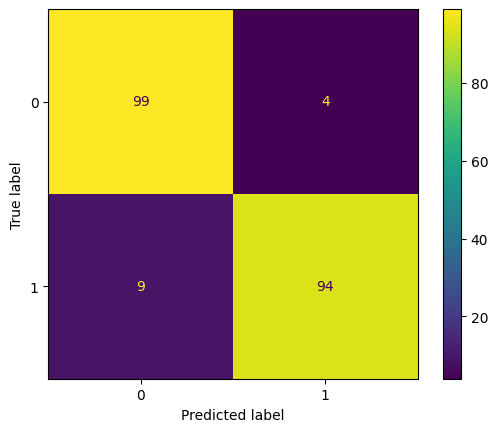

In [38]:
y_pred_knn_tr = knn_grid_search.best_estimator_.predict(X_train)
cm_knn_tr = confusion_matrix(y_train, y_pred_knn_tr)
cm_display_knn_tr = ConfusionMatrixDisplay(confusion_matrix = cm_knn_tr)
cm_display_knn_tr.plot()
plt.show()

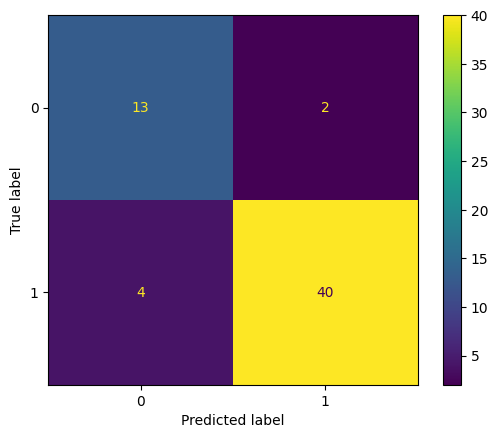

In [39]:
y_pred_knn = knn_grid_search.best_estimator_.predict(X_test)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_display_knn = ConfusionMatrixDisplay(confusion_matrix = cm_knn)
cm_display_knn.plot()
plt.show()

In [40]:
round(recall_score(y_train, y_pred_knn_tr), 3)

0.913

In [41]:
round(recall_score(y_test, y_pred_knn), 3)

0.909

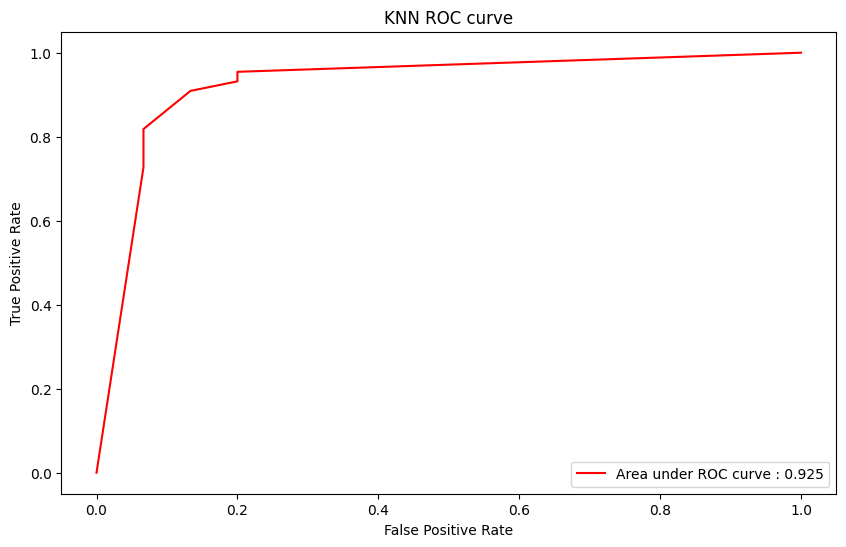

In [42]:
knn_probs = knn_grid_search.best_estimator_.predict_proba(X_test)[: , 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)
plt.figure(figsize = (10 , 6))
plt.plot(fpr_knn, tpr_knn, color = 'red', label = f'Area under ROC curve : {round(roc_auc_score(y_test, knn_probs), 3)}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC curve')
plt.legend(loc = 'lower right')
plt.show()

GRID SEARCH WITH CROSS VALIDATION FOR SVM

In [43]:
svm_param_grid = [
    { 
        'C' : [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10],
        'gamma' : [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
    }
]

svm_grid_search = GridSearchCV(estimator = SVC(probability = True, random_state = 0),
                             param_grid = svm_param_grid,
                             cv = KFold(n_splits = 10, shuffle = True, random_state = 0),
                             scoring = 'recall',
                             n_jobs = -1,
                             )
svm_grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=SVC(probability=True, random_state=0), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10],
                          'gamma': [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5,
                                    10]}],
             scoring='recall')

In [44]:
svm_grid_search.best_params_

{'C': 0.1, 'gamma': 10}

In [45]:
cv_svm = cross_val_score(estimator = svm_grid_search.best_estimator_, X = X_train, y = y_train, cv = KFold(n_splits = 10, shuffle = True, random_state = 0), scoring = 'recall', n_jobs = -1)

In [46]:
for i in range(10):
    print(f'Score in fold {i + 1} : {round(cv_svm.tolist()[i],3)}')
print(f'Mean Score : {round(cv_svm.mean(), 3)}')
print(f'Standard Deviation : {round(cv_svm.std(), 3)}')


Score in fold 1 : 1.0
Score in fold 2 : 1.0
Score in fold 3 : 1.0
Score in fold 4 : 1.0
Score in fold 5 : 1.0
Score in fold 6 : 0.917
Score in fold 7 : 0.846
Score in fold 8 : 1.0
Score in fold 9 : 0.889
Score in fold 10 : 0.9
Mean Score : 0.955
Standard Deviation : 0.057


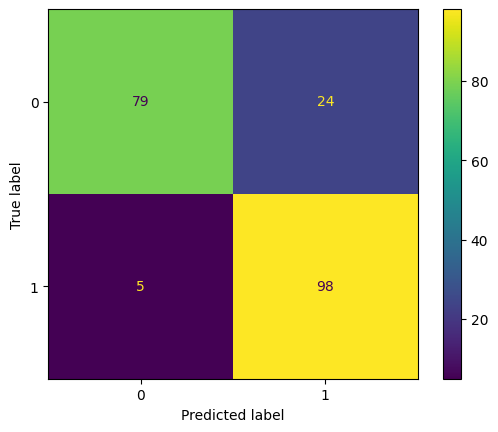

In [47]:
y_pred_svm_tr = svm_grid_search.best_estimator_.predict(X_train)
cm_svm_tr = confusion_matrix(y_train, y_pred_svm_tr)
cm_display_svm_tr = ConfusionMatrixDisplay(confusion_matrix = cm_svm_tr)
cm_display_svm_tr.plot()
plt.show()

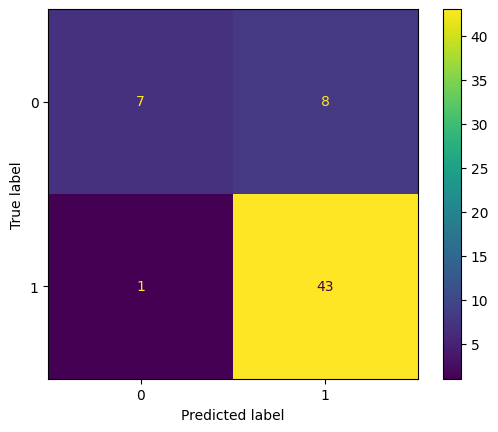

In [48]:
y_pred_svm = svm_grid_search.best_estimator_.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_display_svm = ConfusionMatrixDisplay(confusion_matrix = cm_svm)
cm_display_svm.plot()
plt.show()

In [49]:
round(recall_score(y_train, y_pred_svm_tr), 3)

0.951

In [50]:
round(recall_score(y_test, y_pred_svm), 3)

0.977

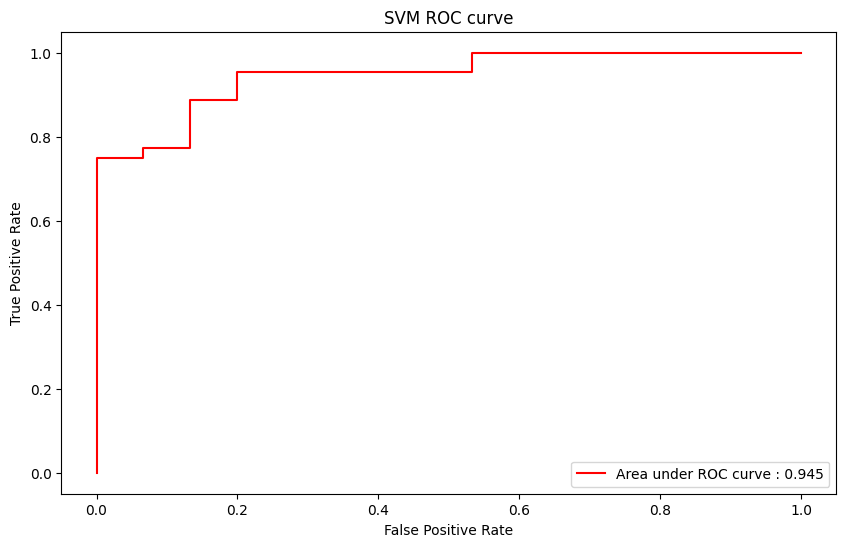

In [51]:
svm_probs = svm_grid_search.best_estimator_.predict_proba(X_test)[: , 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
plt.figure(figsize = (10 , 6))
plt.plot(fpr_svm, tpr_svm, color = 'red', label = f'Area under ROC curve : {round(roc_auc_score(y_test, svm_probs), 3)}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC curve')
plt.legend(loc = 'lower right')
plt.show()

GRID SEARCH WITH CROSS VALIDATION FOR RANDOM FOREST

In [52]:
rf_param_grid = {
    'n_estimators' : [10, 15, 20, 25, 30, 35, 40],
    'max_features' : [1/3, 2/3, 1],
    'max_depth' : [3, 4, 5]
}

rf_grid_search = GridSearchCV(estimator = RandomForestClassifier(random_state = 0),
                             param_grid = rf_param_grid,
                             cv = KFold(n_splits = 10, shuffle = True, random_state = 0),
                             scoring = 'recall',
                             n_jobs = -1
                             )
rf_grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=0, shuffle=True),
             estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5],
                         'max_features': [0.3333333333333333,
                                          0.6666666666666666, 1],
                         'n_estimators': [10, 15, 20, 25, 30, 35, 40]},
             scoring='recall')

In [53]:
rf_grid_search.best_params_

{'max_depth': 5, 'max_features': 0.3333333333333333, 'n_estimators': 10}

In [56]:
cv_rf = cross_val_score(estimator = rf_grid_search.best_estimator_, X = X_train, y = y_train, cv = KFold(n_splits = 10, shuffle = True, random_state = 0), scoring = 'recall', n_jobs = -1)

In [57]:
for i in range(10):
    print(f'Score in fold {i + 1} : {round(cv_rf.tolist()[i],3)}')
print(f'Mean Score : {round(cv_rf.mean(), 3)}')
print(f'Standard Deviation : {round(cv_rf.std(), 3)}')

Score in fold 1 : 1.0
Score in fold 2 : 1.0
Score in fold 3 : 1.0
Score in fold 4 : 1.0
Score in fold 5 : 1.0
Score in fold 6 : 0.667
Score in fold 7 : 0.846
Score in fold 8 : 1.0
Score in fold 9 : 0.889
Score in fold 10 : 0.9
Mean Score : 0.93
Standard Deviation : 0.104


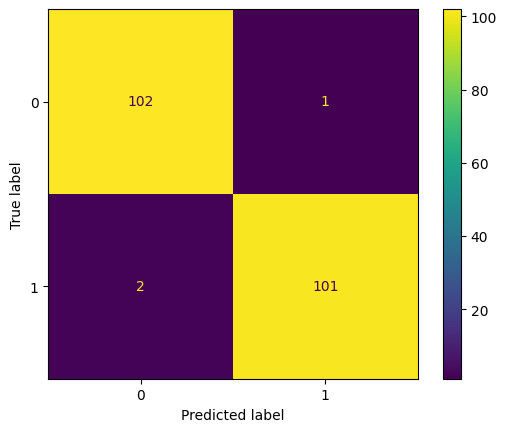

In [58]:
y_pred_rf_tr = rf_grid_search.best_estimator_.predict(X_train)
cm_rf_tr = confusion_matrix(y_train, y_pred_rf_tr)
cm_display_rf_tr = ConfusionMatrixDisplay(confusion_matrix = cm_rf_tr)
cm_display_rf_tr.plot()
plt.show()

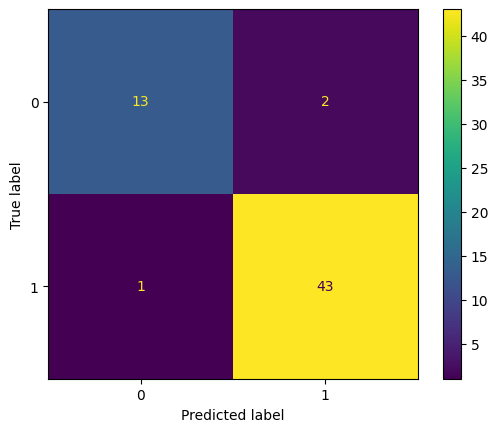

In [59]:
y_pred_rf = rf_grid_search.best_estimator_.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_display_rf = ConfusionMatrixDisplay(confusion_matrix = cm_rf)
cm_display_rf.plot()
plt.show()

In [60]:
round(recall_score(y_train, y_pred_rf_tr), 3)

0.981

In [61]:
round(recall_score(y_test, y_pred_rf), 3)

0.977

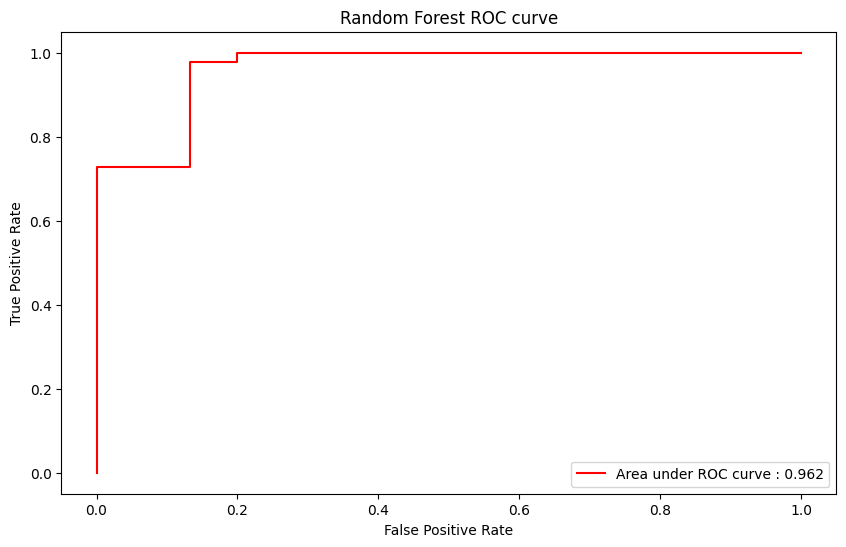

In [62]:
rf_probs = rf_grid_search.best_estimator_.predict_proba(X_test)[: , 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
plt.figure(figsize = (10 , 6))
plt.plot(fpr_rf, tpr_rf, color = 'red', label = f'Area under ROC curve : {round(roc_auc_score(y_test, rf_probs), 3)}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC curve')
plt.legend()
plt.show()

In [63]:
cross_validation_recall_mean, cross_validation_recall_std, train_set_accuracy, train_set_recall, train_set_precision, test_set_accuracy, test_set_recall, test_set_precision, area_under_ROC_curve= [], [], [], [], [], [], [], [], []

In [64]:
cross_validation_recall_mean.append(round(cv_knn.mean(), 3))
cross_validation_recall_std.append(round(cv_knn.std(), 3))
train_set_accuracy.append(round(accuracy_score(y_train, y_pred_knn_tr),3))
train_set_recall.append(round(recall_score(y_train, y_pred_knn_tr), 3))
train_set_precision.append(round(precision_score(y_train, y_pred_knn_tr),3))
test_set_accuracy.append(round(accuracy_score(y_test, y_pred_knn),3))
test_set_recall.append(round(recall_score(y_test, y_pred_knn), 3))
test_set_precision.append(round(precision_score(y_test, y_pred_knn),3))
area_under_ROC_curve.append(round(roc_auc_score(y_test, knn_probs), 3))
cross_validation_recall_mean.append(round(cv_svm.mean(), 3))
cross_validation_recall_std.append(round(cv_svm.std(), 3))
train_set_accuracy.append(round(accuracy_score(y_train, y_pred_svm_tr),3))
train_set_recall.append(round(recall_score(y_train, y_pred_svm_tr), 3))
train_set_precision.append(round(precision_score(y_train, y_pred_svm_tr),3))
test_set_accuracy.append(round(accuracy_score(y_test, y_pred_svm),3))
test_set_recall.append(round(recall_score(y_test, y_pred_svm), 3))
test_set_precision.append(round(precision_score(y_test, y_pred_svm),3))  
area_under_ROC_curve.append(round(roc_auc_score(y_test, svm_probs), 3))
cross_validation_recall_mean.append(round(cv_rf.mean(), 3))
cross_validation_recall_std.append(round(cv_rf.std(), 3))
train_set_accuracy.append(round(accuracy_score(y_train, y_pred_rf_tr),3))
train_set_recall.append(round(recall_score(y_train, y_pred_rf_tr), 3))
train_set_precision.append(round(precision_score(y_train, y_pred_rf_tr),3))
test_set_accuracy.append(round(accuracy_score(y_test, y_pred_rf),3))
test_set_recall.append(round(recall_score(y_test, y_pred_rf), 3))
test_set_precision.append(round(precision_score(y_test, y_pred_rf),3)) 
area_under_ROC_curve.append(round(roc_auc_score(y_test, rf_probs), 3))

In [65]:
algorithms = ['K-Nearest Neighbors', 'Support Vector Machines', 'Random Forest']
df_results = pd.DataFrame({
                           'Algorithm' : algorithms,
                           'Cross Validation Recall Mean' : cross_validation_recall_mean,
                           'Cross Validation Recall Standard Deviation' : cross_validation_recall_std,
                           'Train Set Accuracy' : train_set_accuracy,
                           'Train Set Recall' : train_set_recall,
                           'Train Set Precision' : train_set_precision,
                           'Test Set Accuracy' : test_set_accuracy,
                           'Test Set Recall' : test_set_recall,
                           'Test Set Precision' : test_set_precision,
                           'Area under ROC curve' : area_under_ROC_curve
                           })
df_results

,Algorithm,Cross Validation Recall Mean,Cross Validation Recall Standard Deviation,Train Set Accuracy,Train Set Recall,Train Set Precision,Test Set Accuracy,Test Set Recall,Test Set Precision,Area under ROC curve
0,K-Nearest Neighbors,0.910,0.089,0.937,0.913,0.959,0.898,0.909,0.952,0.925
1,Support Vector Machines,0.955,0.057,0.859,0.951,0.803,0.847,0.977,0.843,0.945
2,Random Forest,0.930,0.104,0.985,0.981,0.990,0.949,0.977,0.956,0.962
